In [1]:
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
spy = pd.read_csv(
    "../data/processed/spy_returns.csv",
    parse_dates=["Date"],
    index_col="Date"
    )
spy.head()

,Adj Close,Close,High,Low,Open,Volume,Simple_Return,Log_Return,Rolling_Mean_20,Rolling_Volatility_20
Date,,,,,,,,,,
2010-01-04,84.578484,113.330002,113.389999,111.510002,112.370003,118944600,NaN,NaN,NaN,NaN
2010-01-05,84.802368,113.629997,113.680000,112.849998,113.260002,111579900,0.002647,0.002644,NaN,NaN
2010-01-06,84.862068,113.709999,113.989998,113.430000,113.519997,116074400,0.000704,0.000704,NaN,NaN
2010-01-07,85.220306,114.190002,114.330002,113.180000,113.500000,131091100,0.004221,0.004213,NaN,NaN
2010-01-08,85.503891,114.570000,114.620003,113.660004,113.889999,126402800,0.003328,0.003322,NaN,NaN


In [3]:
spy.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4197 entries, 2010-01-04 to 2026-09-10
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Adj Close              4197 non-null   float64
 1   Close                  4197 non-null   float64
 2   High                   4197 non-null   float64
 3   Low                    4197 non-null   float64
 4   Open                   4197 non-null   float64
 5   Volume                 4197 non-null   int64  
 6   Simple_Return          4196 non-null   float64
 7   Log_Return             4196 non-null   float64
 8   Rolling_Mean_20        4177 non-null   float64
 9   Rolling_Volatility_20  4177 non-null   float64
dtypes: float64(9), int64(1)
memory usage: 360.7 KB


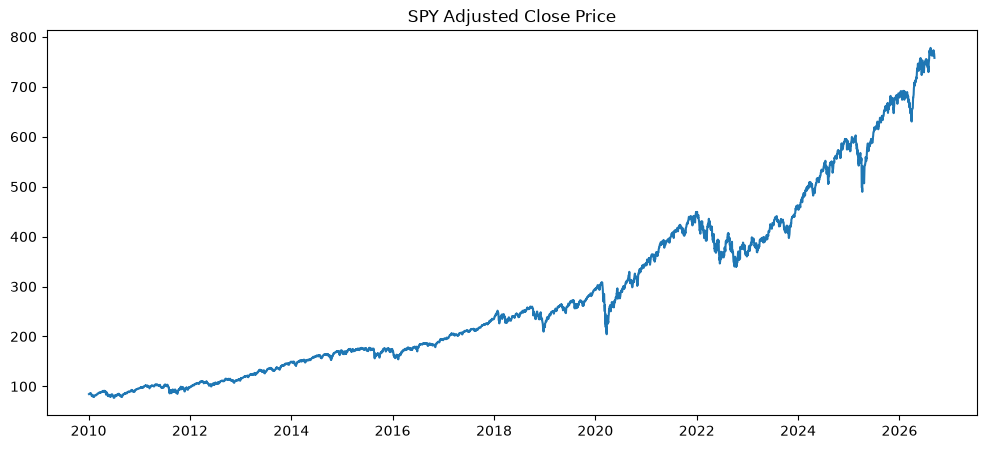

In [4]:
plt.figure(figsize=(12, 5))
plt.plot(spy.index, spy["Adj Close"])
plt.title("SPY Adjusted Close Price")
plt.show()

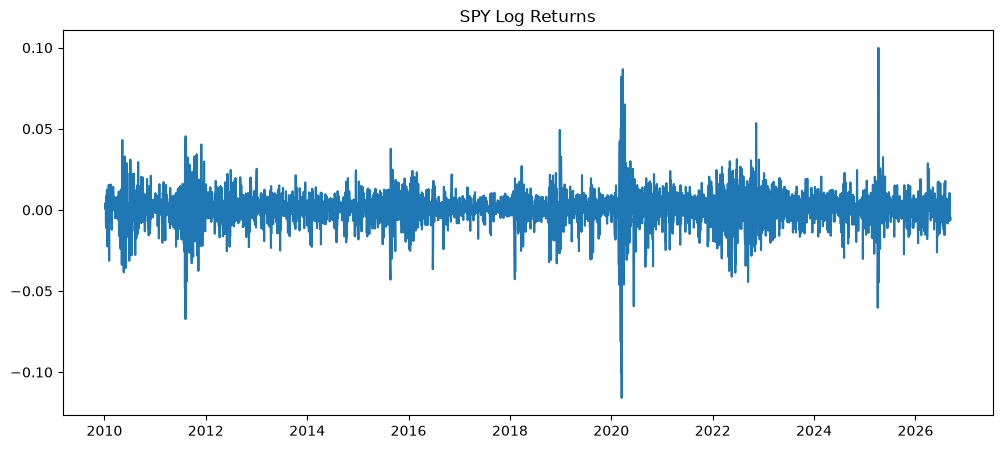

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(spy.index, spy["Log_Return"])
plt.title("SPY Log Returns")
plt.show()

In [6]:
from statsmodels.tsa.stattools import adfuller

In [7]:
#ADF Test
def adf_test(series, name="Series"):
    result = adfuller(series.dropna())

    print(f"ADF Test: {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])

    print("Critical Values:")

    for key, value in result[4].items():
        print(f"   {key}: {value}")

In [8]:
adf_test(
    spy["Adj Close"],
    "SPY Price"
)

ADF Test: SPY Price
ADF Statistic: 2.3192046638239763
p-value: 0.9989670616011074
Critical Values:
   1%: -3.4319202742722204
   5%: -2.8622338609034434
   10%: -2.5671393482375984


C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\484690825.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [9]:
adf_test(
    spy["Log_Return"],
    "SPY Log Returns"
)

ADF Test: SPY Log Returns
ADF Statistic: -14.018999686656148
p-value: 3.5995907013654955e-26
Critical Values:
   1%: -3.4319195204978277
   5%: -2.8622335279191637
   10%: -2.567139170972099


C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\484690825.py:3: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  result = adfuller(series.dropna())


In [10]:
#KPSS Test
from statsmodels.tsa.stattools import kpss

In [11]:
def kpss_test(series, name="Series"):
    statistic, p_value, lags, critical_values = kpss(
        series.dropna(),
        regression="c",
        nlags="auto"
    )

    print(f"KPSS Test: {name}")
    print("KPSS Statistic:", statistic)
    print("p-value:", p_value)

    print("Critical Values:")

    for key, value in critical_values.items():
        print(f"   {key}: {value}")

In [12]:
kpss_test(
    spy["Adj Close"],
    "SPY Price"
)

KPSS Test: SPY Price
KPSS Statistic: 9.246885596801901
p-value: 0.01
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\2947214558.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is smaller than the p-value returned.
  statistic, p_value, lags, critical_values = kpss(
C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\2947214558.py:2: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, critical_values = kpss(


In [13]:
kpss_test(
    spy["Log_Return"],
    "SPY Log Returns"
)

KPSS Test: SPY Log Returns
KPSS Statistic: 0.029308117613410695
p-value: 0.1
Critical Values:
   10%: 0.347
   5%: 0.463
   2.5%: 0.574
   1%: 0.739


C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\2947214558.py:2: InterpolationWarning: The test statistic is outside of the range of p-values available in the look-up table. The actual p-value is greater than the p-value returned.
  statistic, p_value, lags, critical_values = kpss(
C:\Users\Dinithi Jayakody\AppData\Local\Temp\ipykernel_5872\2947214558.py:2: FutureWarning: kpss currently returns a plain tuple whose length and layout depends on the store argument (and which silently drops `lags` when store=True). In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning a KPSSResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  statistic, p_value, lags, critical_values = kpss(


In [14]:
from statsmodels.graphics.tsaplots import plot_acf

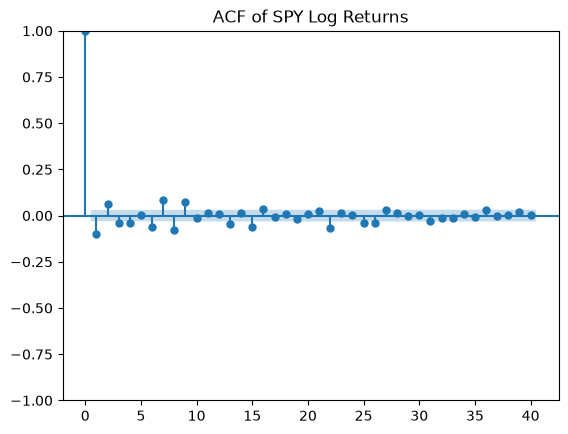

In [15]:
plot_acf(
    spy["Log_Return"].dropna(),
    lags=40
)

plt.title("ACF of SPY Log Returns")
plt.show()